
# Practical 3: Overfit Prevention (Regularization, Dropout, Early Stopping, Batch Normalization)

This is **Practical 3** of the **Hands-On Computer Vision Series**.

- In **Practical 1**, we built a very simple neural network.
- In **Practical 2**, we added **activation functions** (ReLU) and trained on the **same flower dataset**.
- **Now**, we keep the **same dataset and nearly the same code**, and add **four small upgrades** to reduce **overfitting**:

    - L2 Regularization
    - Dropout
    - EarlyStopping
    - BatchNormalization

We’ll reuse the same pipeline and model shape, then toggle one idea at a time.


In [ ]:

# Import required libraries (same as Practical 2, plus regularizers for L2)
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras import regularizers


In [ ]:

# Define image size and class names (same as Practical 2)
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_CHANNELS = 3
CLASS_NAMES = ["daisy", "dandelion", "roses", "sunflowers", "tulips"]



## Dataset & Loader

We use the **Google Cloud-hosted flower dataset** in CSV format and the **same parsing code**.


In [ ]:
# Load dataset from CSV and parse image-label pairs
def read_and_decode(filename, resize_dims):
    img_bytes = tf.io.read_file(filename)
    img = tf.image.decode_jpeg(img_bytes, channels=IMG_CHANNELS)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize(img, resize_dims)
    return img

def parse_csvline(csv_line):
    record_default = ["", ""]
    filename, label_string = tf.io.decode_csv(csv_line, record_default)
    img = read_and_decode(filename, [IMG_HEIGHT, IMG_WIDTH])
    label = tf.argmax(tf.math.equal(CLASS_NAMES, label_string))
    return img, label


In [ ]:
# You can change the batch size here to 16, 32, 64, etc.
# Load training and evaluation datasets from Google Cloud
train_dataset = (
    tf.data.TextLineDataset("gs://cloud-ml-data/img/flower_photos/train_set.csv")
    .map(parse_csvline, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(16)
    .prefetch(tf.data.AUTOTUNE)
)

eval_dataset = (
    tf.data.TextLineDataset("gs://cloud-ml-data/img/flower_photos/eval_set.csv")
    .map(parse_csvline, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(16)
    .prefetch(tf.data.AUTOTUNE)
)


## Helper: Plot Training vs Validation

We’ll reuse a tiny helper to visualize loss/accuracy quickly.


In [ ]:

def plot_history(h, title):
    plt.figure()
    plt.plot(h.history.get("loss", []), label="train_loss")
    plt.plot(h.history.get("val_loss", []), label="val_loss")
    plt.title(title + " — Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.show()

    plt.figure()
    plt.plot(h.history.get("accuracy", []), label="train_acc")
    plt.plot(h.history.get("val_accuracy", []), label="val_acc")
    plt.title(title + " — Accuracy")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.show()



## Baseline

We keep the same **Network with ReLU** you used in P2.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    19,267,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,284,869 (73.57 MB)

 Trainable params: 19,284,869 (73.57 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
    207/Unknown 276s 1s/step - accuracy: 0.2893 - loss: 13.3734

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


207/207 ━━━━━━━━━━━━━━━━━━━━ 309s 1s/step - accuracy: 0.2894 - loss: 13.3429 - val_accuracy: 0.4000 - val_loss: 1.9578
Epoch 2/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 250s 1s/step - accuracy: 0.3850 - loss: 2.0706 - val_accuracy: 0.3757 - val_loss: 1.8323
Epoch 3/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 198s 902ms/step - accuracy: 0.4098 - loss: 1.6673 - val_accuracy: 0.3216 - val_loss: 1.9555
Epoch 4/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 198s 884ms/step - accuracy: 0.4521 - loss: 1.5450 - val_accuracy: 0.3784 - val_loss: 1.3852
Epoch 5/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 204s 896ms/step - accuracy: 0.4266 - loss: 1.4577 - val_accuracy: 0.2811 - val_loss: 2.3815
Epoch 6/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 140s 676ms/step - accuracy: 0.3928 - loss: 1.5598 - val_accuracy: 0.2973 - val_loss: 1.5818
Epoch 7/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 144s 695ms/step - accuracy: 0.3416 - loss: 1.4917 - val_accuracy: 0.3892 - val_loss: 1.5058
Epoch 8/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 200s 686ms/step - accuracy: 0.4234 - loss: 1.3336 - 

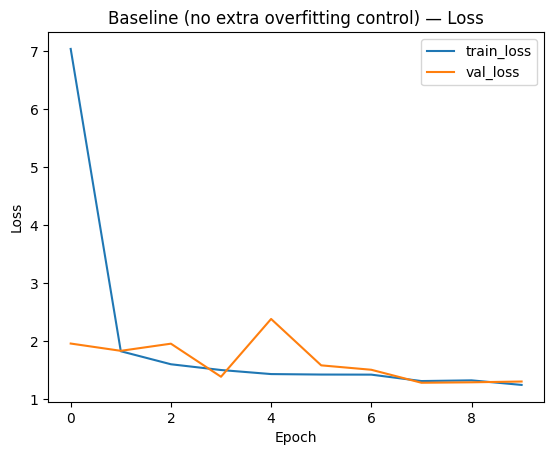

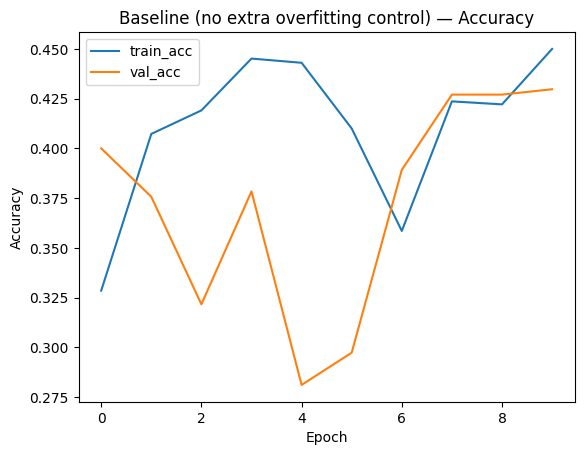

In [ ]:
# Build the model with activation functions (same as P2)
baseline = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(5, activation='softmax')
])
baseline.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)
baseline.summary()
history_base = baseline.fit(train_dataset, validation_data=eval_dataset, epochs=10)
plot_history(history_base, "Baseline (no extra overfitting control)")



## L2 Regularization (Weight Decay)

**Idea:** discourage very **large weights** → simpler models that generalize better.

**Code change:** add `kernel_regularizer=regularizers.l2(1e-4)` to Dense layers.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
    207/Unknown 115s 543ms/step - accuracy: 0.3051 - loss: 13.0633

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


207/207 ━━━━━━━━━━━━━━━━━━━━ 131s 621ms/step - accuracy: 0.3053 - loss: 13.0343 - val_accuracy: 0.4000 - val_loss: 2.1343
Epoch 2/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 139s 670ms/step - accuracy: 0.3863 - loss: 1.9011 - val_accuracy: 0.4243 - val_loss: 1.5159
Epoch 3/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 141s 667ms/step - accuracy: 0.4411 - loss: 1.5318 - val_accuracy: 0.3730 - val_loss: 1.5705
Epoch 4/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 142s 687ms/step - accuracy: 0.4287 - loss: 1.4456 - val_accuracy: 0.4649 - val_loss: 1.3592
Epoch 5/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 202s 688ms/step - accuracy: 0.4245 - loss: 1.4396 - val_accuracy: 0.4784 - val_loss: 1.3803
Epoch 6/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 202s 689ms/step - accuracy: 0.4067 - loss: 1.3938 - val_accuracy: 0.4324 - val_loss: 1.4344
Epoch 7/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 201s 687ms/step - accuracy: 0.4258 - loss: 1.3768 - val_accuracy: 0.3757 - val_loss: 1.4905
Epoch 8/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 182s 589ms/step - accuracy: 0.4240 - loss: 1.3

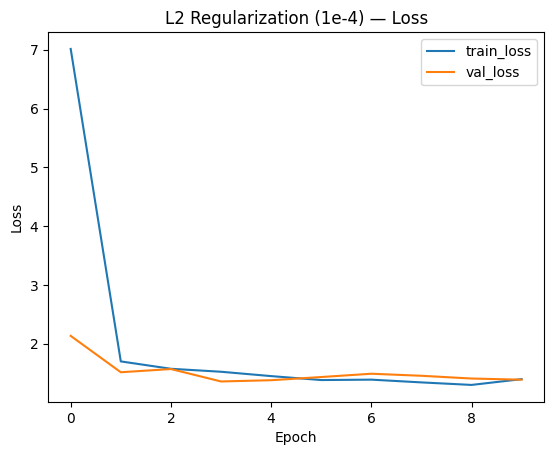

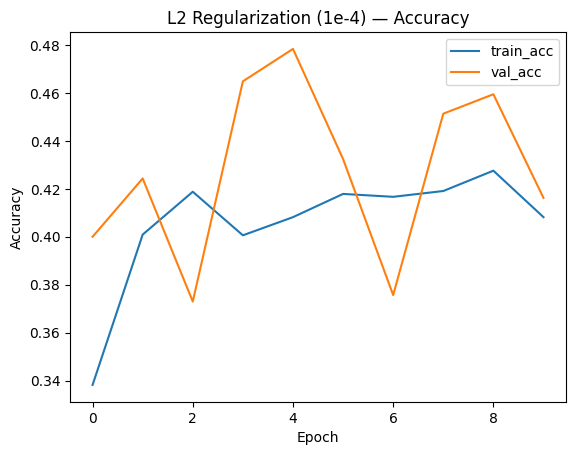

In [ ]:

l2_model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    tf.keras.layers.Dense(5, activation='softmax', kernel_regularizer=regularizers.l2(1e-4))
])
l2_model.compile(optimizer=tf.keras.optimizers.Adam(0.001),
                 loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                 metrics=['accuracy'])
hist_l2 = l2_model.fit(train_dataset, validation_data=eval_dataset, epochs=10)
plot_history(hist_l2, "L2 Regularization (1e-4)")



## Dropout (turn off some neurons while training)

**Idea:** randomly drop a fraction of neurons to avoid **co‑adaptation**.

**Code change:** insert `tf.keras.layers.Dropout(0.5)` **after** ReLU.


Epoch 1/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 129s 608ms/step - accuracy: 0.2219 - loss: 16.8618 - val_accuracy: 0.2351 - val_loss: 1.6079
Epoch 2/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 140s 610ms/step - accuracy: 0.2390 - loss: 1.6077 - val_accuracy: 0.2459 - val_loss: 1.6183
Epoch 3/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 142s 608ms/step - accuracy: 0.2356 - loss: 1.6290 - val_accuracy: 0.2351 - val_loss: 1.6096
Epoch 4/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 140s 597ms/step - accuracy: 0.2391 - loss: 1.6088 - val_accuracy: 0.2351 - val_loss: 1.6100
Epoch 5/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 202s 889ms/step - accuracy: 0.2392 - loss: 1.6015 - val_accuracy: 0.2351 - val_loss: 1.6102
Epoch 6/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 142s 685ms/step - accuracy: 0.2373 - loss: 1.6152 - val_accuracy: 0.2351 - val_loss: 1.6102
Epoch 7/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 142s 684ms/step - accuracy: 0.2392 - loss: 1.6031 - val_accuracy: 0.2351 - val_loss: 1.6102
Epoch 8/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 122s 587ms/step - accuracy: 0.2392 

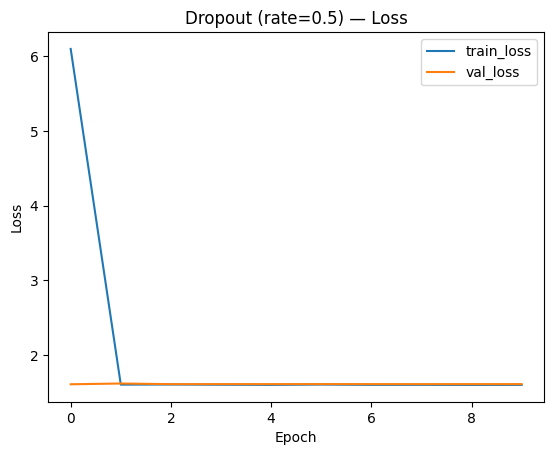

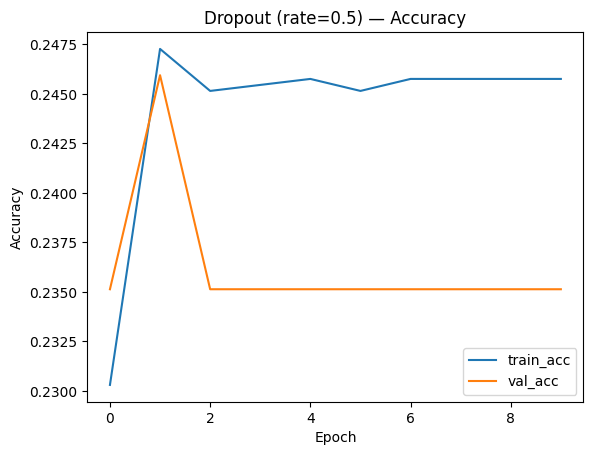

In [ ]:

drop_model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(5, activation='softmax')
])
drop_model.compile(optimizer=tf.keras.optimizers.Adam(0.001),
                   loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                   metrics=['accuracy'])
hist_drop = drop_model.fit(train_dataset, validation_data=eval_dataset, epochs=10)
plot_history(hist_drop, "Dropout (rate=0.5)")



## EarlyStopping (stop when validation stops improving)

**Idea:** monitor `val_loss` and **stop early** to avoid overfitting.

**Code change:** add an EarlyStopping callback (no architecture change).


Epoch 1/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 123s 586ms/step - accuracy: 0.3030 - loss: 12.0854 - val_accuracy: 0.3514 - val_loss: 2.5373
Epoch 2/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 141s 682ms/step - accuracy: 0.3797 - loss: 1.9303 - val_accuracy: 0.3757 - val_loss: 1.8628
Epoch 3/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 142s 684ms/step - accuracy: 0.4339 - loss: 1.5425 - val_accuracy: 0.3216 - val_loss: 1.8925
Epoch 4/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 120s 581ms/step - accuracy: 0.3906 - loss: 1.5035 - val_accuracy: 0.3946 - val_loss: 1.4657
Epoch 5/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 142s 685ms/step - accuracy: 0.3820 - loss: 1.3646 - val_accuracy: 0.3838 - val_loss: 1.4366
Epoch 6/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 142s 687ms/step - accuracy: 0.3868 - loss: 1.3417 - val_accuracy: 0.4297 - val_loss: 1.3510
Epoch 7/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 202s 687ms/step - accuracy: 0.4137 - loss: 1.3082 - val_accuracy: 0.4486 - val_loss: 1.3144
Epoch 8/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 202s 688ms/step - accuracy: 0.4065 

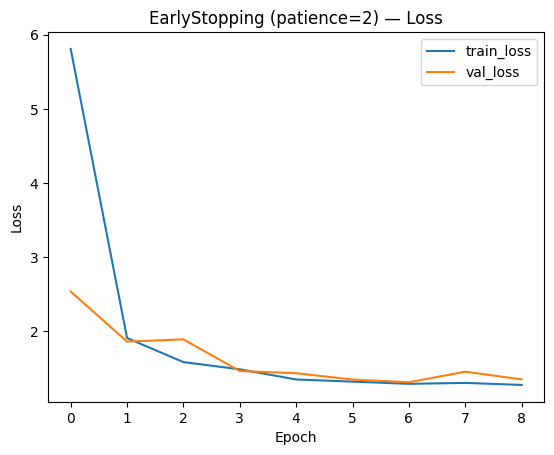

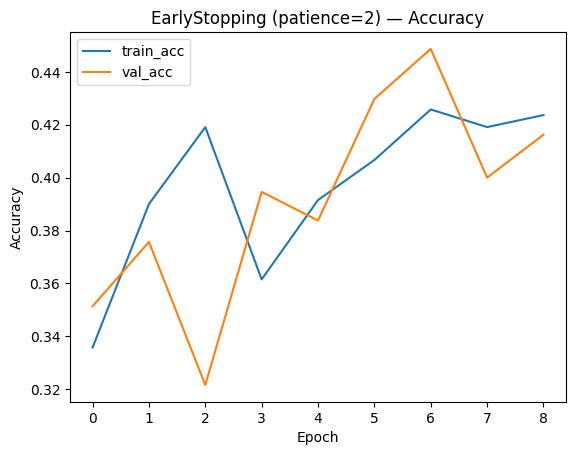

In [ ]:

es_cb = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)
es_model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(5, activation='softmax')
])
es_model.compile(optimizer=tf.keras.optimizers.Adam(0.001),
                 loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                 metrics=['accuracy'])
hist_es = es_model.fit(train_dataset, validation_data=eval_dataset, epochs=10, callbacks=[es_cb])
plot_history(hist_es, "EarlyStopping (patience=2)")



## BatchNormalization (stabilize activations)

**Idea:** normalize layer activations → **smoother training** and often better generalization.

**Code pattern:** Dense → **BatchNormalization** → Activation.


Epoch 1/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 224s 1s/step - accuracy: 0.3676 - loss: 1.5236 - val_accuracy: 0.4162 - val_loss: 1.2897
Epoch 2/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 179s 865ms/step - accuracy: 0.5040 - loss: 1.2129 - val_accuracy: 0.4838 - val_loss: 1.2098
Epoch 3/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 199s 961ms/step - accuracy: 0.5813 - loss: 1.0641 - val_accuracy: 0.4027 - val_loss: 1.3934
Epoch 4/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 141s 681ms/step - accuracy: 0.7070 - loss: 0.8726 - val_accuracy: 0.3811 - val_loss: 1.5760
Epoch 5/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 137s 658ms/step - accuracy: 0.7844 - loss: 0.7010 - val_accuracy: 0.3676 - val_loss: 1.9269
Epoch 6/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 137s 635ms/step - accuracy: 0.8640 - loss: 0.5548 - val_accuracy: 0.3541 - val_loss: 1.9705
Epoch 7/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 140s 624ms/step - accuracy: 0.8656 - loss: 0.5025 - val_accuracy: 0.3838 - val_loss: 2.1150
Epoch 8/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 138s 605ms/step - accuracy: 0.9169 - lo

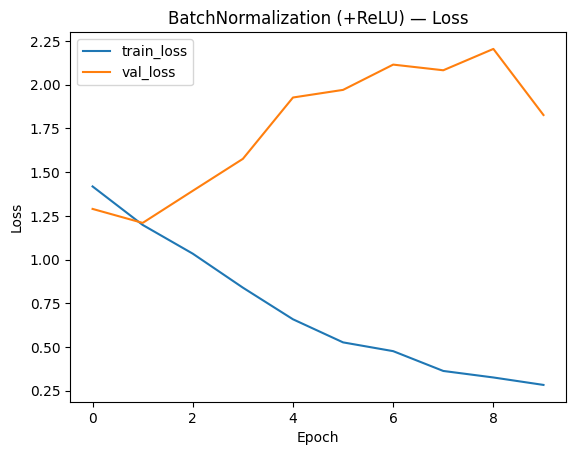

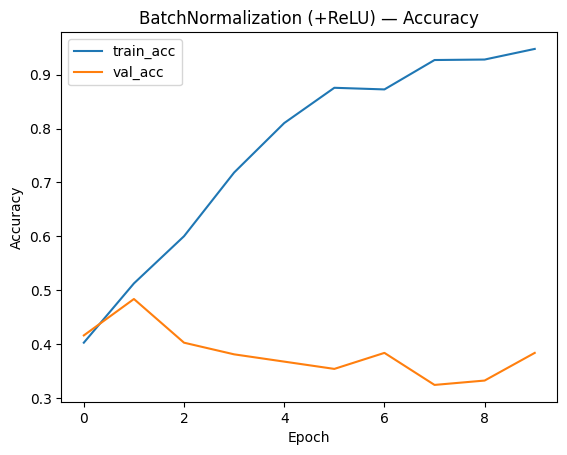

In [ ]:

bn_model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    tf.keras.layers.Dense(128),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.Dense(128),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.Dense(5),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('softmax')
])
bn_model.compile(optimizer=tf.keras.optimizers.Adam(0.001),
                 loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                 metrics=['accuracy'])
hist_bn = bn_model.fit(train_dataset, validation_data=eval_dataset, epochs=10)
plot_history(hist_bn, "BatchNormalization (+ReLU)")



## Combine them

A small recipe that often works well:
**L2 + BatchNorm + ReLU + Dropout + EarlyStopping**


Epoch 1/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 130s 605ms/step - accuracy: 0.3224 - loss: 1.7219 - val_accuracy: 0.4081 - val_loss: 1.4441
Epoch 2/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 142s 616ms/step - accuracy: 0.4259 - loss: 1.4558 - val_accuracy: 0.4378 - val_loss: 1.4549
Epoch 3/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 142s 685ms/step - accuracy: 0.4517 - loss: 1.3969 - val_accuracy: 0.4676 - val_loss: 1.3868
Epoch 4/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 141s 683ms/step - accuracy: 0.4827 - loss: 1.3684 - val_accuracy: 0.4649 - val_loss: 1.3945
Epoch 5/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 118s 569ms/step - accuracy: 0.4727 - loss: 1.3537 - val_accuracy: 0.4838 - val_loss: 1.4159


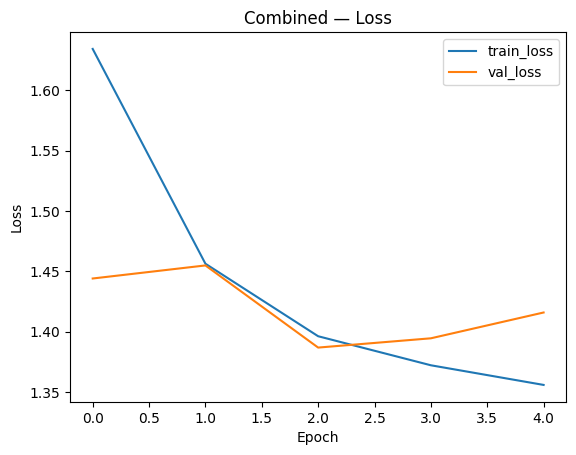

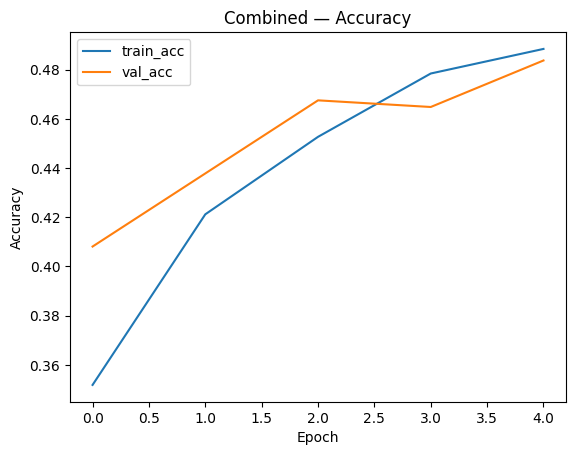

In [ ]:

combo_cb = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)
combo_model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    tf.keras.layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(5, kernel_regularizer=regularizers.l2(1e-4)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('softmax')
])
combo_model.compile(optimizer=tf.keras.optimizers.Adam(0.001),
                    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                    metrics=['accuracy'])
hist_combo = combo_model.fit(train_dataset, validation_data=eval_dataset, epochs=10, callbacks=[combo_cb])
plot_history(hist_combo, "Combined")


# Note: Simple Network + Regularization Can Look “Worse”

Sometimes our base CNN is **too simple** (low capacity). When we add L1/L2, Dropout, or strong EarlyStopping, we further reduce capacity and the model may **underfit**—both training and validation accuracy can be low, or validation can drop slightly compared to the unregularized small model.

**This does not mean the tools are bad.** It means the network needs **more expressive power**. On a **deeper/wider CNN** or a **pre‑trained model (transfer learning)**, these tools usually:

- reduce the **train–validation gap** (less overfitting),

- improve **generalization** on new images,

- make training **more stable**.


## What to remember

- **Use the same base code** as P2 and add **one technique at a time**.
- **Overfitting signs:** train improves while validation stalls or gets worse.
- **Quick fixes to try:** L2 (1e‑4 to 5e‑4), Dropout (0.3–0.6), EarlyStopping (patience 2–4), BatchNorm before activation.
- Start simple, then **combine** for more stable results.


# Quick Recap: Why We Add These Tools
Overfitting happens when a model memorizes the training images but performs poorly on new images. To keep our model **simple, general, and stable**, we use:

- **L2 (weight decay)** to gently shrink weights and reduce complexity
- **Dropout** to prevent co-adaptation (the model can't depend on a small set of neurons)
- **EarlyStopping** to stop training when validation stops improving
- **Batch Normalization** to stabilize and speed up training

In this practical we also add **L1** regularization and compare it with L2.


# L1 vs L2 Regularization (Weight Penalties)
Regularization adds a small **penalty** to the loss so the network prefers simpler weights.

**Formulas (you do not need to memorize them):**
- **L2** adds: $\lambda \sum w^2$  → pushes weights toward **small values** (smoothly)
- **L1** adds: $\lambda \sum |w|$   → pushes many weights to **exactly zero** (sparse)

**Intuition:**
- L2 is like a soft rubber band pulling weights toward zero.
- L1 is like a sharp clip that snaps many small weights to zero (feature selection).

**When to prefer:**
- Use **L2** most of the time for CNNs; it’s smooth and works well with SGD/Adam.
- Try **L1** when you want sparsity or when features may be noisy.

**Tip:** You can combine both using `tf.keras.regularizers.l1_l2(l1=..., l2=...)` (a.k.a. Elastic Net).


In [ ]:
# 🧪 Minimal L1 example (same dataset, same style as previous practicals)
# We show how to add L1 to Conv2D/Dense layers.
# Keep lambda values small (e.g., 1e-4 to 1e-3). Larger values can underfit.

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

l1_strength = 1e-4  # try 1e-4 or 5e-5

def build_l1_model(input_shape=(180, 180, 3), num_classes=5):
    reg = keras.regularizers.l1(l1_strength)

    inputs = keras.Input(shape=input_shape)

    # Block 1
    x = layers.Conv2D(32, 3, padding="same", activation="relu", kernel_regularizer=reg)(inputs)
    x = layers.BatchNormalization()(x)  # BN helps training stability
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.2)(x)  # small dropout early in the network

    # Block 2
    x = layers.Conv2D(64, 3, padding="same", activation="relu", kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.3)(x)

    # Head
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu", kernel_regularizer=reg)(x)
    x = layers.Dropout(0.5)(x)  # stronger dropout before the classifier
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="flowers_l1_regularized")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

l1_model = build_l1_model()
l1_model.summary(print_fn=lambda x: print(x))

# NOTE: Use the SAME training/validation datasets you built earlier.
# Example (reusing variables from Practical 2/3):
# history = l1_model.fit(train_ds, validation_data=val_ds, epochs=20,
#                        callbacks=[early_stopping_callback])


# Dropout (Randomly Turning Off Neurons During Training)
- **What it does:** At each training step, randomly drops (turns off) a fraction of neurons.
- **Why it helps:** The model can’t rely on just a few neurons, so it learns **robust, general features**.
- **How to use:** Place after dense/conv blocks, use small rates early (0.1–0.3), larger before the final layer (0.4–0.6).

**Example** (already used above): `layers.Dropout(0.5)`


# EarlyStopping (Stop When Validation Stops Improving)
- **What it does:** Watches the **validation loss** (or accuracy). If it doesn’t improve for a while, it stops training.
- **Why it helps:** Prevents wasting time and avoids overfitting after the best point.
- **How to use:**
```python
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)
```
- **Tip:** `restore_best_weights=True` gives you the best model.


# Batch Normalization (Stable and Faster Training)
- **What it does:** Normalizes activations inside the network.
- **Why it helps:** Reduces internal covariate shift, allows **larger learning rates** and **faster convergence**.
- **How to use:** Put BN **after convolution and before activation** (or with activation='linear' + separate activation). In Keras it’s common and fine to apply BN right after a `Conv2D` with `activation='relu'` as well, which we keep for simplicity.


# Bonus: Elastic Net (L1 + L2 Together)
If you want sparsity **and** smooth shrinkage:

```python
reg = tf.keras.regularizers.l1_l2(l1=1e-5, l2=1e-4)
layers.Dense(128, activation='relu', kernel_regularizer=reg)
```
Start with small values and tune on validation performance.


# What’s Next (Practical 4): Transfer Learning
In the next practical, we will **reuse a pre-trained CNN** (e.g., MobileNetV2) and fine-tune it on our flowers dataset. This usually gives **higher accuracy with fewer images and fewer epochs**. We’ll learn:

- How to **freeze** base layers and train only a small classifier head
- How to **unfreeze** top blocks and fine-tune safely
- Which **data augmentations** work best with transfer learning


---

*This practical was designed to give you hands‑on practice with **overfitting‑prevention tools**—**L1/L2 regularization, Dropout, EarlyStopping, and Batch Normalization** and to help you analyze **real training/validation behavior** to understand **capacity vs. generalization**. It connects directly to Practicals 1 & 2 and gets you ready for **Transfer Learning** next.*